In [2]:
pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
modelo = YOLO('yolov8n.pt')
print('Modelo carregado com sucesso!')
print(f'Classes: {len(modelo.names)} categorias')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo carregado com sucesso!
Classes: 80 categorias


# Parte 1 – Detecção de Objetos em Imagens

In [4]:
from ultralytics import YOLO
import cv2
from google.colab import files
uploaded = files.upload()
# 1. Carregar o modelo pre-treinado
modelo = YOLO('yolov8n.pt')
# 2. Executar a deteccao
resultados = modelo('foto_teste.jpg')
# 3. Exibir os resultados no terminal
for r in resultados:
 for box in r.boxes:
  classe = modelo.names[int(box.cls)]
  confianca = float(box.conf)
  coords = box.xyxy[0].tolist()
  print(f'{classe}: {confianca:.2f} | bbox: {coords}')
# 4. Salvar a imagem com as deteccoes desenhadas
img_resultado = resultados[0].plot()
cv2.imwrite('resultado_deteccao.jpg', img_resultado)
print('Imagem salva como resultado_deteccao.jpg')

Saving foto_teste.jpg to foto_teste.jpg

image 1/1 /content/foto_teste.jpg: 448x640 1 cup, 2 clocks, 320.6ms
Speed: 11.3ms preprocess, 320.6ms inference, 35.1ms postprocess per image at shape (1, 3, 448, 640)
clock: 0.67 | bbox: [137.54847717285156, 181.90065002441406, 243.5850830078125, 295.3809509277344]
cup: 0.58 | bbox: [250.65122985839844, 297.7278137207031, 356.3125915527344, 425.3872985839844]
clock: 0.34 | bbox: [124.31553649902344, 152.70611572265625, 263.5545349121094, 300.40985107421875]
Imagem salva como resultado_deteccao.jpg


In [5]:
# a) Alterar o limiar de confianca
resultados_a = modelo('foto_teste.jpg', conf=0.25)
resultados_b = modelo('foto_teste.jpg', conf=0.70)
# b) Alterar o tamanho da imagem de entrada
resultados_c = modelo('foto_teste.jpg', imgsz=320)
resultados_d = modelo('foto_teste.jpg', imgsz=640)
# c) Filtrar apenas certas classes (ex: 0=pessoa, 2=carro)
resultados_e = modelo('foto_teste.jpg', classes=[0, 2])


image 1/1 /content/foto_teste.jpg: 448x640 1 cup, 2 clocks, 175.3ms
Speed: 2.6ms preprocess, 175.3ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/foto_teste.jpg: 448x640 (no detections), 168.6ms
Speed: 2.6ms preprocess, 168.6ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/foto_teste.jpg: 224x320 1 clock, 91.9ms
Speed: 1.1ms preprocess, 91.9ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 320)

image 1/1 /content/foto_teste.jpg: 448x640 1 cup, 2 clocks, 363.1ms
Speed: 4.5ms preprocess, 363.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/foto_teste.jpg: 448x640 (no detections), 343.7ms
Speed: 8.3ms preprocess, 343.7ms inference, 8.0ms postprocess per image at shape (1, 3, 448, 640)


 # Parte 2 – Detecção em Vídeo

In [6]:
from ultralytics import YOLO
import cv2
from google.colab import files
uploaded = files.upload()
# Carregar o modelo
modelo = YOLO('yolov8n.pt')
# Abrir o video
cap = cv2.VideoCapture('video_teste.mp4')
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
# Criar o escritor de video para salvar o resultado
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('video_resultado.mp4', fourcc, fps, (largura, altura))
frame_num = 0
while cap.isOpened():
 ret, frame = cap.read()
 if not ret:
  break
 # Detectar objetos no frame
 resultados = modelo(frame, verbose=False)
 frame_anotado = resultados[0].plot()
 # Contar deteccoes
 n_objetos = len(resultados[0].boxes)
 frame_num += 1
 print(f'Frame {frame_num}: {n_objetos} objetos detectados')
 out.write(frame_anotado)
cap.release()
out.release()
print('Video salvo como video_resultado.mp4')

Saving video_teste.mp4 to video_teste.mp4
Frame 1: 6 objetos detectados
Frame 2: 7 objetos detectados
Frame 3: 8 objetos detectados
Frame 4: 8 objetos detectados
Frame 5: 8 objetos detectados
Frame 6: 5 objetos detectados
Frame 7: 6 objetos detectados
Frame 8: 5 objetos detectados
Frame 9: 5 objetos detectados
Frame 10: 5 objetos detectados
Frame 11: 6 objetos detectados
Frame 12: 5 objetos detectados
Frame 13: 4 objetos detectados
Frame 14: 4 objetos detectados
Frame 15: 4 objetos detectados
Frame 16: 6 objetos detectados
Frame 17: 5 objetos detectados
Frame 18: 5 objetos detectados
Frame 19: 6 objetos detectados
Frame 20: 7 objetos detectados
Frame 21: 6 objetos detectados
Frame 22: 5 objetos detectados
Frame 23: 5 objetos detectados
Frame 24: 5 objetos detectados
Frame 25: 5 objetos detectados
Frame 26: 6 objetos detectados
Frame 27: 6 objetos detectados
Frame 28: 6 objetos detectados
Frame 29: 6 objetos detectados
Frame 30: 7 objetos detectados
Frame 31: 7 objetos detectados
Frame 

Saving video_teste.mp4 to video_teste (1).mp4
Frame 1: 6 objetos detectados
Frame 2: 7 objetos detectados
Frame 3: 8 objetos detectados
Frame 4: 8 objetos detectados
Frame 5: 8 objetos detectados
Frame 6: 5 objetos detectados
Frame 7: 6 objetos detectados
Frame 8: 5 objetos detectados
Frame 9: 5 objetos detectados
Frame 10: 5 objetos detectados
Frame 11: 6 objetos detectados
Frame 12: 5 objetos detectados
Frame 13: 4 objetos detectados
Frame 14: 4 objetos detectados
Frame 15: 4 objetos detectados
Frame 16: 6 objetos detectados
Frame 17: 5 objetos detectados
Frame 18: 5 objetos detectados
Frame 19: 6 objetos detectados
Frame 20: 7 objetos detectados
Frame 21: 6 objetos detectados
Frame 22: 5 objetos detectados
Frame 23: 5 objetos detectados
Frame 24: 5 objetos detectados
Frame 25: 5 objetos detectados
Frame 26: 6 objetos detectados
Frame 27: 6 objetos detectados
Frame 28: 6 objetos detectados
Frame 29: 6 objetos detectados
Frame 30: 7 objetos detectados
Frame 31: 7 objetos detectados
Fr

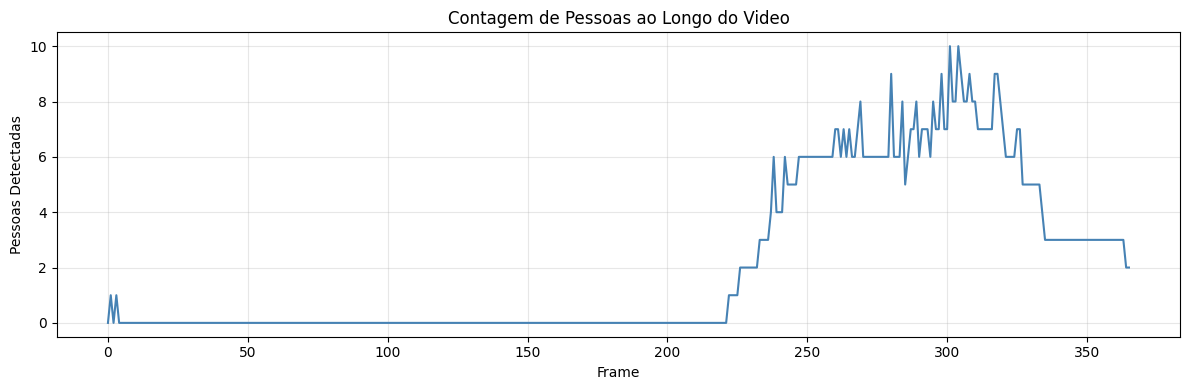

In [10]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
# Carregar o modelo
modelo = YOLO('yolov8n.pt')
contagem_pessoas = [] # preencha durante o loop de frames

# Abrir o video
cap = cv2.VideoCapture('video_teste.mp4')
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
# Criar o escritor de video para salvar o resultado
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('video_resultado.mp4', fourcc, fps, (largura, altura))
frame_num = 0
while cap.isOpened():
 ret, frame = cap.read()
 if not ret:
  break
 # Detectar objetos no frame
 resultados = modelo(frame, verbose=False)
 frame_anotado = resultados[0].plot()
 # Dentro do loop, apos a deteccao, adicione:
 n_pessoas = sum(1 for box in resultados[0].boxes
   if modelo.names[int(box.cls)] == 'person')
 contagem_pessoas.append(n_pessoas)
 # Contar deteccoes
 n_objetos = len(resultados[0].boxes)
 frame_num += 1
 print(f'Frame {frame_num}: {n_objetos} objetos detectados')
 out.write(frame_anotado)
cap.release()
out.release()
print('Video salvo como video_resultado.mp4')
# Apos o loop, gere o grafico:
plt.figure(figsize=(12, 4))
plt.plot(contagem_pessoas, color='steelblue')
plt.xlabel('Frame')
plt.ylabel('Pessoas Detectadas')
plt.title('Contagem de Pessoas ao Longo do Video')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_contagem.png')
plt.show()

# Parte 3 – Detecção em Tempo Real (Webcam)

In [ ]:
from ultralytics import YOLO
import cv2
import time
modelo = YOLO('yolov8n.pt')
cap = cv2.VideoCapture(0) # 0 = webcam padrao
if not cap.isOpened():
 print('Erro: webcam nao encontrada!')
 exit()
print('Pressione Q para sair...')
while True:
 ret, frame = cap.read()
 if not ret:
  break
 inicio = time.time()
 resultados = modelo(frame, verbose=False)
 fim = time.time()
 # Calcular FPS
 fps = 1 / (fim - inicio)
 # Desenhar deteccoes
 frame_anotado = resultados[0].plot()
 # Exibir FPS no canto superior
 cv2.putText(frame_anotado, f'FPS: {fps:.1f}',
 (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
 1, (0, 255, 0), 2)
 cv2.imshow('YOLO - Deteccao em Tempo Real', frame_anotado)
 if cv2.waitKey(1) & 0xFF == ord('q'):
  break
cap.release()
cv2.destroyAllWindows()

In [ ]:
from ultralytics import YOLO
import cv2
import time
modelo = YOLO('yolov8n.pt')
cap = cv2.VideoCapture(0) # 0 = webcam padrao
if not cap.isOpened():
 print('Erro: webcam nao encontrada!')
 exit()
print('Pressione Q para sair...')
while True:
 ret, frame = cap.read()
 if not ret:
  break
 inicio = time.time()
 resultados = modelo(frame, verbose=False)
 fim = time.time()
 # Verificar se 'cell phone' (classe 67) foi detectado
 classes_detectadas = [modelo.names[int(c)] for c in resultados[0].boxes.cls]
 if 'cell phone' in classes_detectadas:
  cv2.putText(frame_anotado, 'CELULAR DETECTADO!',
 (10, 70), cv2.FONT_HERSHEY_SIMPLEX,
 1, (0, 0, 255), 3)
 # Borda vermelha de alerta
 cv2.rectangle(frame_anotado, (0, 0),
 (frame_anotado.shape[1], frame_anotado.shape[0]),
 (0, 0, 255), 10)
 # Calcular FPS
 fps = 1 / (fim - inicio)
 # Desenhar deteccoes
 frame_anotado = resultados[0].plot()
 # Exibir FPS no canto superior
 cv2.putText(frame_anotado, f'FPS: {fps:.1f}',
 (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
 1, (0, 255, 0), 2)
 cv2.imshow('YOLO - Deteccao em Tempo Real', frame_anotado)
 if cv2.waitKey(1) & 0xFF == ord('q'):
  break
cap.release()
cv2.destroyAllWindows()